# Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import csv  
from pathlib import Path 
import re

In [2]:
os.getcwd()

'/home/simonque/Documents/code/NYCU_AI_HAR_project'

# Get all folders in the dataset dir

In [3]:
def get_all_raw_ds_folder_paths(dataset_dir):
    # all folders in the raw dataset folder
    folders = [f.name for f in dataset_dir.iterdir() if f.is_dir()]
    # eg. cycling_1, running_2, jumprope_1, ...
    pattern = r'.+_\d+'
    folder_results = sorted([f for f in folders if re.search(pattern, f)])
    print(folder_results)
    folder_results = [Path(dataset_dir, folder) for folder in folder_results]
    print(folder_results)
    return folder_results

In [4]:
dataset_dir = Path("./raw_dataset/")
raw_ds_folders = get_all_raw_ds_folder_paths(dataset_dir)
raw_ds_folders

['cycling_1', 'cycling_2', 'cycling_3', 'cycling_4', 'downstairs_1', 'downstairs_2', 'jumprope_1', 'running_1', 'upstairs_1', 'upstairs_2']
[PosixPath('raw_dataset/cycling_1'), PosixPath('raw_dataset/cycling_2'), PosixPath('raw_dataset/cycling_3'), PosixPath('raw_dataset/cycling_4'), PosixPath('raw_dataset/downstairs_1'), PosixPath('raw_dataset/downstairs_2'), PosixPath('raw_dataset/jumprope_1'), PosixPath('raw_dataset/running_1'), PosixPath('raw_dataset/upstairs_1'), PosixPath('raw_dataset/upstairs_2')]


[PosixPath('raw_dataset/cycling_1'),
 PosixPath('raw_dataset/cycling_2'),
 PosixPath('raw_dataset/cycling_3'),
 PosixPath('raw_dataset/cycling_4'),
 PosixPath('raw_dataset/downstairs_1'),
 PosixPath('raw_dataset/downstairs_2'),
 PosixPath('raw_dataset/jumprope_1'),
 PosixPath('raw_dataset/running_1'),
 PosixPath('raw_dataset/upstairs_1'),
 PosixPath('raw_dataset/upstairs_2')]

# Create a folder for the resulting processed IMU data

In [5]:
final_dataset_folder = "./final_dataset" 
os.makedirs(final_dataset_folder, exist_ok=True)

# Select phyphox experiment and read its data 

Read the accelerometer, gyroscope, and pressure data from the selected folder

## Read sensor data into dataframe

In [24]:
def read_sensor_data_from_raw_ds_folder(raw_ds_folder):
    # 1. Load your data (assuming CSVs from Phyphox)
    # read timestamp, accelerometer, gyroscope, and pressure  
    df_accl = pd.read_csv(Path(raw_ds_folder, "Accelerometer.csv"))
    print(f"accelerometer dataframe shape: f{df_accl.shape}")
    df_gyro = pd.read_csv(Path(raw_ds_folder, "Gyroscope.csv"))
    print(f"gyroscope dataframe shape: f{df_gyro.shape}")
    df_pres = pd.read_csv(Path(raw_ds_folder, "Pressure.csv"))
    print(f"pressure dataframe shape: f{df_pres.shape}")
    # accelerometer, gyroscope, pressure 
    return df_accl, df_gyro, df_pres

## Timestamp

In [25]:
def combine_resample_dfs(df_accl = None, df_gyro = None, df_pres = None):
    # Let's assume 'time' is the column name from Phyphox
    # Convert the 'time' column to a Timedelta or Datetime index 
    df_accl.columns = ["time", "acc_x", "acc_y", "acc_z"]
    df_accl["time"] = pd.to_timedelta(df_accl["time"], unit='s')
    df_accl.set_index('time', inplace=True)

    df_gyro.columns = ["time", "rot_x", "rot_y", "rot_z"]
    df_gyro["time"] = pd.to_timedelta(df_gyro["time"], unit='s')
    df_gyro.set_index('time', inplace=True)

    # Combine accelerometer and gyroscope rows with outer join
    # 2. Merge (Sync) the sensors
    # 'outer' join ensures we don't lose data from either sensor
    df_combined = df_accl.join(df_gyro, how="outer") 

    # 3. Interpolate and Resample to 50Hz (20ms intervals)
    # First, fill the NaNs created by the slight misalignment
    df_combined = df_combined.interpolate(method='linear')
    # Now, resample to exactly 50Hz
    # '20L' stands for 20 milliseconds
    df_resampled = df_combined.resample('20ms').mean()
    
    # Drop any remaining NaNs at the very start/end
    df_resampled.dropna(inplace=True)
    
    return df_resampled


In [26]:
df_resampled.shape

(30219, 6)

## Save the 50 Hz resampled and combined dataframe

In [31]:
def save_combined_resampled_df(df_resampled, raw_ds_folder):
    dst_filepath = f"{raw_ds_folder}_combined_resampled.csv" 
    df_resampled.to_csv(dst_filepath)


In [32]:
raw_ds_folder = raw_ds_folders[0]
df_accl, df_gyro, df_pres = read_sensor_data_from_raw_ds_folder(raw_ds_folder)
df_resampled = combine_resample_dfs(df_accl, df_gyro)
df_resampled.info()
save_combined_resampled_df(df_resampled, raw_ds_folder)

accelerometer dataframe shape: f(36264, 4)
gyroscope dataframe shape: f(36261, 4)
pressure dataframe shape: f(15103, 2)
<class 'pandas.DataFrame'>
TimedeltaIndex: 30219 entries, 0 days 00:00:00.064279957 to 0 days 00:10:04.464279957
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   acc_x   30219 non-null  float64
 1   acc_y   30219 non-null  float64
 2   acc_z   30219 non-null  float64
 3   rot_x   30219 non-null  float64
 4   rot_y   30219 non-null  float64
 5   rot_z   30219 non-null  float64
dtypes: float64(6)
memory usage: 1.6 MB


In [34]:
df_resampled.head()

,acc_x,acc_y,acc_z,rot_x,rot_y,rot_z
time,,,,,,
0 days 00:00:00.064279957,2.252842,4.794618,7.951350,-0.111177,0.222813,-0.041157
0 days 00:00:00.084279957,2.208575,4.722634,8.102098,-0.111177,0.222813,-0.041157
0 days 00:00:00.104279957,2.431108,4.579264,8.492128,-0.014966,0.056963,-0.013668
0 days 00:00:00.124279957,2.670390,4.645665,8.380861,0.009468,0.101556,-0.020184
0 days 00:00:00.144279957,2.705086,4.609773,8.147561,0.007789,0.142331,-0.035048


# Do this in a loop for all experiments


In [35]:
print(raw_ds_folders)

[PosixPath('raw_dataset/cycling_1'), PosixPath('raw_dataset/cycling_2'), PosixPath('raw_dataset/cycling_3'), PosixPath('raw_dataset/cycling_4'), PosixPath('raw_dataset/downstairs_1'), PosixPath('raw_dataset/downstairs_2'), PosixPath('raw_dataset/jumprope_1'), PosixPath('raw_dataset/running_1'), PosixPath('raw_dataset/upstairs_1'), PosixPath('raw_dataset/upstairs_2')]


In [36]:
for raw_ds_folder_path in raw_ds_folders:
    df_accl, df_gyro, df_pres = read_sensor_data_from_raw_ds_folder(raw_ds_folder_path)
    df_resampled = combine_resample_dfs(df_accl, df_gyro)
    df_resampled.info()
    save_combined_resampled_df(df_resampled, raw_ds_folder_path)
    

accelerometer dataframe shape: f(36264, 4)
gyroscope dataframe shape: f(36261, 4)
pressure dataframe shape: f(15103, 2)
<class 'pandas.DataFrame'>
TimedeltaIndex: 30219 entries, 0 days 00:00:00.064279957 to 0 days 00:10:04.464279957
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   acc_x   30219 non-null  float64
 1   acc_y   30219 non-null  float64
 2   acc_z   30219 non-null  float64
 3   rot_x   30219 non-null  float64
 4   rot_y   30219 non-null  float64
 5   rot_z   30219 non-null  float64
dtypes: float64(6)
memory usage: 1.6 MB
accelerometer dataframe shape: f(16137, 4)
gyroscope dataframe shape: f(16136, 4)
pressure dataframe shape: f(6718, 2)
<class 'pandas.DataFrame'>
TimedeltaIndex: 13445 entries, 0 days 00:00:00.049293179 to 0 days 00:04:28.949293179
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   acc_x   13445 non-null  float64
 1   acc_y   13445 non-n

In [39]:
os.listdir("raw_dataset/")

['downstairs_1_combined_resampled.csv',
 'downstairs_2_combined_resampled.csv',
 'cycling_2',
 'cycling_4',
 'upstairs_2.zip',
 'cycling_3_combined_resampled.csv',
 'cycling_1.zip',
 'jumprope_1',
 'downstairs_2.zip',
 'cycling_4.zip',
 'cycling_1_combined_resampled.csv',
 'jumprope_1_combined_resampled.csv',
 'jumprope.zip',
 'cycling_3.zip',
 'downstairs_2',
 'running.zip',
 'downstairs_1',
 'cycling_4_combined_resampled.csv',
 'running_1',
 'cycling_2.zip',
 'running_1_combined_resampled.csv',
 'upstairs_1',
 'upstairs_1.zip',
 'upstairs_2_combined_resampled.csv',
 '.ipynb_checkpoints',
 'cycling_3',
 'cycling_1',
 'upstairs_2',
 'downstairs_1.zip',
 'cycling_2_combined_resampled.csv',
 'upstairs_1_combined_resampled.csv']

# Code for matplotlib slider

In [40]:
# !pip install ipympl ipywidgets --user --break-system-packages


In [32]:
!jupyter labextension enable widgetsnbextension

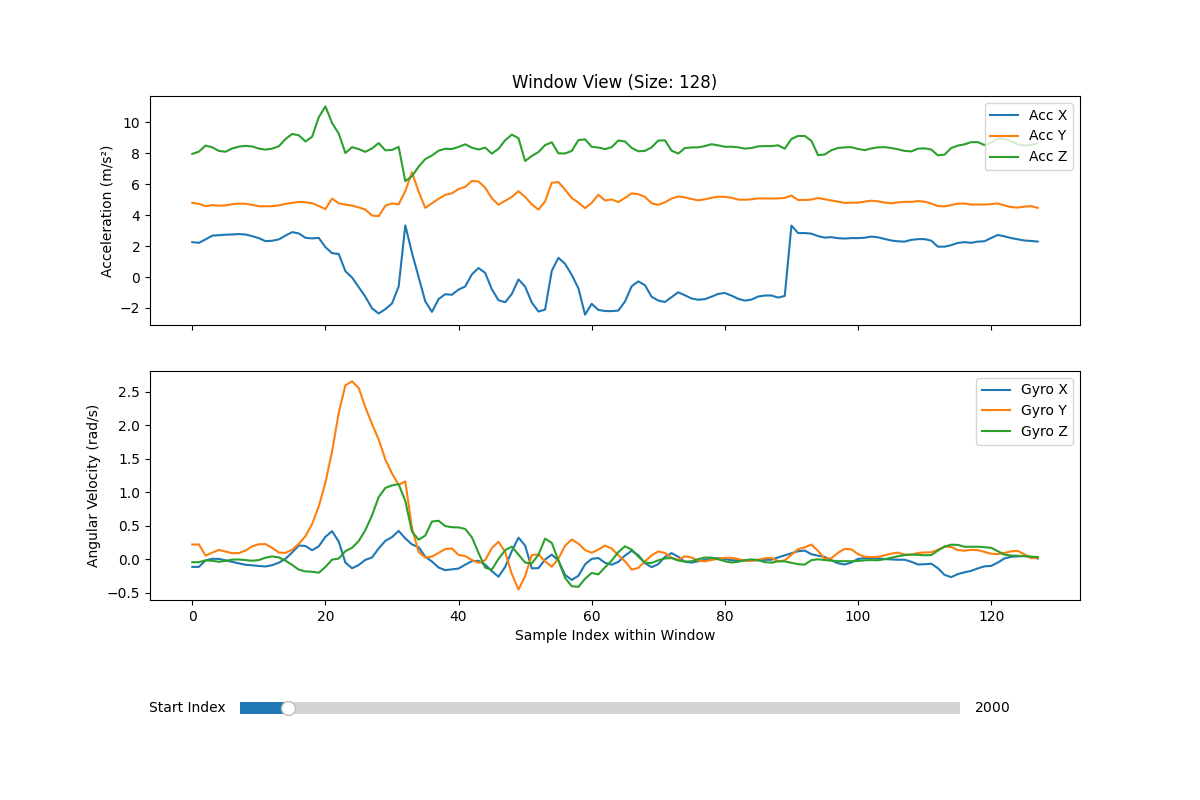

In [36]:
%matplotlib ipympl
plot_interactive_windows(df_resampled)